<a href="https://colab.research.google.com/github/joandavid-cicese/taller_Foro_Seguridad/blob/main/Practica1_foro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Práctica Aprendizaje Supervisado

# Ejercicio 1: Aprendizaje supervisado para clasificación de url maliciosas

En esta práctica veremos una serie de pasos de forma detallada para crear un algoritmo de ML, de aprendizaje supervisado, que será el encargado de realizar la tarea de clasificación de url entre 'legítima' o 'maliciosa'.

Caso de uso: Implementamos dicho modelo en un contenedor, o API donde le llegan las url de los correos, hace la clasificación: legítima o maliciosa.

## Paso 1: Importar librerías necesarias

In [1]:
import pandas as pd # para leer datasets
import numpy as np # para trabajar con arrays
from urllib.parse import urlparse
import re # Regex para encontrar un formato de IP
import os # para trabajar con el sistema de archivos
from sklearn.model_selection import train_test_split # para dividir los datos en entrenamiento y prueba
from sklearn.ensemble import RandomForestClassifier # para crear un algoritmo de Bosque Aleatorio de Clasificación
from sklearn.linear_model import LogisticRegression # para crear un algortimo de Regresión Logística
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report # métricas de evaluación
import seaborn as sns # para graficar
from sklearn.metrics import roc_curve, auc # para graficar la curva ROC
import matplotlib.pyplot as plt # para graficar
from sklearn.preprocessing import StandardScaler # para escalar las características

Para cargar los datos, se puede realizar de varias formas:
- desde el directorio de archivos.
- si estamos en google colab, desde google drive.
- directamente desde una url.
- Desde la plataforma Kaggle que tiene un gran conjunto de datasets para diferentes proyectos.
- Entre otras...

## Paso 2: Cargar los datos

https://www.kaggle.com/datasets/hassaanmustafavi/phishing-urls-dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hassaanmustafavi/phishing-urls-dataset")

print("Path to dataset files:", path)

100%|██████████| 7.56M/7.56M [00:01<00:00, 7.56MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hassaanmustafavi/phishing-urls-dataset/versions/1


In [4]:
try:
    file_path = os.path.join(path, "url_dataset.csv") # pasamos la ruta + el nombre del dataset
    df = pd.read_csv(file_path) # lo convertimos a un DataFrame de pandas para poder trabajar
    print("Dataset cargado exitosamente.")
except Exception as e:
    print(f"Error al cargar el dataset: {e}")
    print("Por favor, verifique el enlace o descargue el archivo manualmente.")

Dataset cargado exitosamente.


In [ ]:
# Vistazo rápido a los datos
print(df.head()) # muestra las 5 primeras filas del dataset
print(f"\nForma del dataset: {df.shape}") # muestra el tamaño del dataset (filas, columnas)

counts = df['type'].value_counts()
print(f"Distribución de etiquetas:\n{counts}")

                         url        type
0     https://www.google.com  legitimate
1    https://www.youtube.com  legitimate
2   https://www.facebook.com  legitimate
3      https://www.baidu.com  legitimate
4  https://www.wikipedia.org  legitimate

Forma del dataset: (450176, 2)
Distribución de etiquetas:
type
legitimate    345738
phishing      104438
Name: count, dtype: int64


### Gráficos de distribución de etiquetas

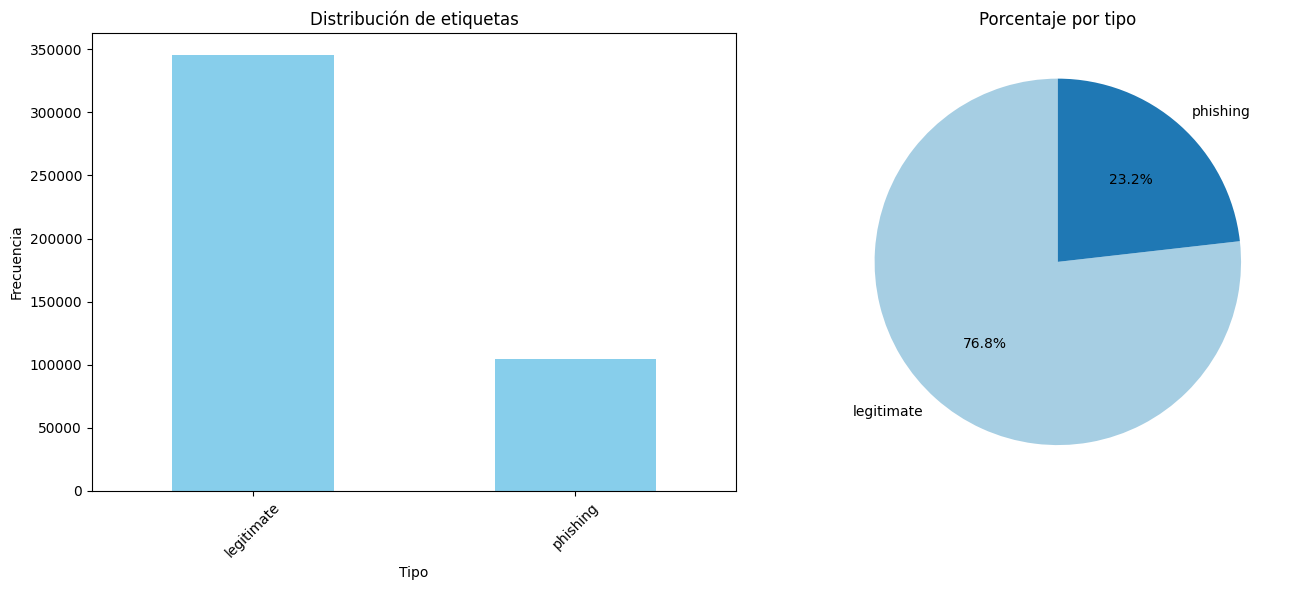

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # 1 fila y 2 columnas

# Gráfico de barras
counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de etiquetas')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico de pastel
counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
axes[1].set_title('Porcentaje por tipo')
axes[1].set_ylabel('')  # Ocultar eje Y

# Ajustar espacio
plt.tight_layout()
plt.show()

## Paso 3: Ingeniería de Características (Feature Engineering)

In [ ]:
df['url_length'] = df['url'].apply(len) # Característica 1: Longitud de la URL

In [ ]:
df['has_at'] = df['url'].apply(lambda x: 1 if '@' in x else 0) # Característica 2: Presencia del símbolo '@'

Qué es lambda?
- es una función anónima, es decir, una función que no tiene un nombre explícito. Estas funciones son útiles cuando necesitas crear funciones pequeñas y rápidas, especialmente para tareas simples que no requieren una definición completa con def

In [ ]:
df['dot_count'] = df['url'].apply(lambda x: x.count('.')) # Característica 3: Número de puntos ('.')

In [ ]:
df['has_https'] = df['url'].apply(lambda x: 1 if 'https' in x else 0) # Característica 4: Uso de 'https'

In [ ]:
# Característica 5: Presencia de dirección IP en el dominio
def has_ip_address(url):
    match = re.search(
        r'(([01]?\d\d?|2[0-4]\d|25[0-5])\.([01]?\d\d?|2[0-4]\d|25[0-5])\.([01]?\d\d?|2[0-4]\d|25[0-5])\.'
        r'([01]?\d\d?|2[0-4]\d|25[0-5]))', url) # expresión regular de una IP: X.X.X.X, donde X es de 0 a 255 (en decimal)
    return 1 if match else 0
df['has_ip'] = df['url'].apply(has_ip_address)

Opción 1: [01]?\d\d?

- [01]? = Un 0 ó 1 opcional (el ? significa "puede estar o no")
- \d = Cualquier dígito (0-9)
- \d? = Otro dígito opcional

Ejemplos que acepta: 5, 05, 15, 99, 105, 199

Opción 2: 2[0-4]\d

- 2 = Debe empezar con 2
- [0-4] = Segundo dígito del 0 al 4
- \d = Cualquier tercer dígito

Ejemplos que acepta: 200, 249, 212, 234

Opción 3: 25[0-5]

- 25 = Debe empezar con 25
- [0-5] = Tercer dígito del 0 al 5

Ejemplos que acepta: 250, 255, 251, 254

¿Por qué estas 3 opciones?
¡Porque juntas cubren TODOS los números válidos de 0 a 255!

- 0-199: Opción 1 ([01]?\d\d?)
- 200-249: Opción 2 (2[0-4]\d)
- 250-255: Opción 3 (25[0-5])

¿Por qué es útil esto?

Los sitios web maliciosos a menudo usan direcciones IP directamente en lugar de nombres de dominio normales para:

- Evitar ser bloqueados fácilmente
- Ocultar su identidad
- Hacer phishing o estafas

Este código ayuda a detectar automáticamente esos casos sospechosos en grandes cantidades de datos

In [ ]:
# Característica 6: Número de subdominios
def get_subdomain_count(url):
    try:
        # Extraemos el 'netloc' (ej. www.google.com) y contamos los puntos
        hostname = urlparse(url).netloc
        if hostname:
            # Quitamos www. si existe para no contarlo como subdominio
            if hostname.startswith('www.'):
                hostname = hostname[4:]
            return hostname.count('.')
        return 0
    except:
        return 0
df['subdomain_count'] = df['url'].apply(get_subdomain_count)

In [ ]:
print("Ingeniería de características completada.")
print("Nuevas características añadidas:")
print(df.head())

Ingeniería de características completada.
Nuevas características añadidas:
                         url        type  url_length  has_at  dot_count  \
0     https://www.google.com  legitimate          22       0          2   
1    https://www.youtube.com  legitimate          23       0          2   
2   https://www.facebook.com  legitimate          24       0          2   
3      https://www.baidu.com  legitimate          21       0          2   
4  https://www.wikipedia.org  legitimate          25       0          2   

   has_https  has_ip  subdomain_count  
0          1       0                1  
1          1       0                1  
2          1       0                1  
3          1       0                1  
4          1       0                1  


Ahora podemos ver cómo nuestro dataset pasó de tener apenas 2 columnas, a tener 8 columnas, con características extraídas de solo las url.

## Paso 4: Preparación de Datos

En este punto es importante destacar el por qué solo usamos características numéricas para entrenar nuestros modelos.

In [ ]:
# Seleccionamos las características para el modelo (X) y la etiqueta (y)
features = ['url_length', 'has_at', 'dot_count', 'has_https', 'has_ip', 'subdomain_count'] # todas excepto el 'type' y 'url'
X = df[features] # Variables independientes

In [ ]:
y = df['type'].apply(lambda x: 0 if x == 'legitimate' else 1) # Convertimos las etiquetas de texto a numéricas (codificación)

- df['type']: Selecciona la columna 'type' del DataFrame. Esta columna contiene las etiquetas de texto 'legitimate' (legítimo) o 'phishing' (malicioso).
- .apply(...): Aplica una función a cada elemento de la serie (la columna 'type').
- lambda x: 0 if x == 'legitimate' else 1: Esta es una función anónima (lambda) que toma un valor x (que será cada etiqueta en la columna 'type'). Si x es igual a 'legitimate', la función devuelve 0; de lo contrario, devuelve 1.

El resultado de esta operación es una nueva Serie (que se asigna a la variable y) donde las etiquetas de texto originales se han convertido a valores numéricos: 0 para 'legitimate' y 1 para 'phishing'.

In [ ]:
# Separar los datos en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nDatos listos para entrenar:")
print(f"Tamaño de entrenamiento: {X_train.shape}")
print(f"Tamaño de prueba: {X_test.shape}")


Datos listos para entrenar:
Tamaño de entrenamiento: (360140, 6)
Tamaño de prueba: (90036, 6)


## Paso 5: Entrenamiento del Modelo

In [ ]:
print("\nCreando el modelo RandomForestClassifier...")

# Creamos el clasificador RandomForest
# n_estimators = número de "árboles" en el bosque.
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)


Creando el modelo RandomForestClassifier...


El parámetro n_jobs es una configuración común en modelos de ML que controla el paralelismo durante el entrenamiento y predicción.

¿Qué hace n_jobs?
Determina cuántos procesadores (cores de CPU) se utilizan simultáneamente para ejecutar el algoritmo. Esto es especialmente útil para operaciones que pueden dividirse en tareas independientes.

Valores típicos:
n_jobs=1 (default): Usa un solo core, procesamiento secuencial
n_jobs=-1: Usa todos los cores disponibles en tu máquina
n_jobs=2, 3, 4...: Usa ese número específico de cores

In [ ]:
model.fit(X_train, y_train) # Entrenamos el modelo con los datos de entrenamiento
print("Modelo entrenado.")

Modelo entrenado.


En este punto ya tenemos un modelo de Bosque Aleatorio entrenado con el conjunto de entrenamiento, listo para predecir. el próximo paso es probarlo con los datos de prueba, previamente separados.

## Paso 6: Predicción

In [ ]:
print("\nRealizando predicciones sobre el conjunto de prueba...")
y_pred = model.predict(X_test)


Realizando predicciones sobre el conjunto de prueba...


ahora, el siguiente paso es evaluar qué tal clasificó nuestro modelo con el conjunto de prueba

## Paso 7: Evaluación del Modelo

In [ ]:
print("\n--- Evaluación del Modelo ---")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Accuracy (Exactitud): {accuracy:.4f}")
print(f"Precision (Precisión): {precision:.4f}")
print(f"Recall (Exhaustividad/Sensibilidad): {recall:.4f}")


--- Evaluación del Modelo ---
Accuracy (Exactitud): 0.9917
Precision (Precisión): 0.9924
Recall (Exhaustividad/Sensibilidad): 0.9720


Hasta aquí se pueden ver valores muy buenos de las métricas, mayor al 97%. De igual forma vamos a entender un poco más estas métricas, y qué nos quieren decir.

Estas métricas nos dan una idea del rendimiento del modelo. En nuestro contexto de detección de URLs maliciosas:

- Una alta exactitud indica que el modelo, en general, clasifica correctamente la mayoría de las URLs.
- Una alta precisión es importante si quieres minimizar los falsos positivos (marcar una URL legítima como maliciosa).
- Un alto recall es crucial si quieres minimizar los falsos negativos (no detectar una URL maliciosa real), ya que no detectar una URL de phishing puede tener consecuencias más graves.

### Matriz de confusión

Vamos a mostrar la matriz de confusión. Esta matriz nos dice con qué predicciones el modelo funciona mejor, así como, con cuál se equivoca más.

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:")
print(cm)


Matriz de confusión:
[[68764   157]
 [  592 20523]]


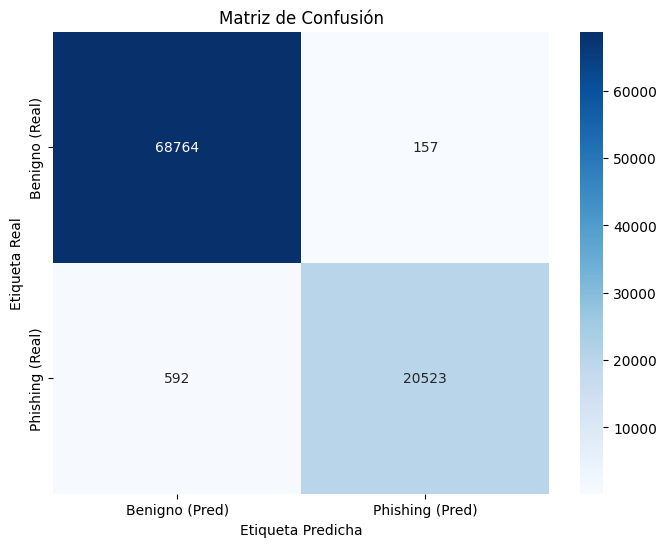

In [ ]:
# Visualización de la Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno (Pred)', 'Phishing (Pred)'],
            yticklabels=['Benigno (Real)', 'Phishing (Real)'])
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión')
plt.show()

Para entender los resultados:
- Verdaderos Negativos (TN): Arriba-Izquierda (URLs benignas correctamente clasificadas)
- Falsos Positivos (FP): Arriba-Derecha (URLs benignas incorrectamente marcadas como phishing)
- Falsos Negativos (FN): Abajo-Izquierda (URLs de phishing incorrectamente marcadas como benignas) <-- ¡EL PEOR ERROR!
- Verdaderos Positivos (TP): Abajo-Derecha (URLs de phishing correctamente clasificadas)

### Métricas de evaluación

In [ ]:
# Reporte completo de métricas
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     68921
           1       0.99      0.97      0.98     21115

    accuracy                           0.99     90036
   macro avg       0.99      0.98      0.99     90036
weighted avg       0.99      0.99      0.99     90036



De igual forma, una vía práctica es hacer una función que calcule las métricas de forma más directar, como se muestra en la celda de abajo

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score

# Calcular métricas con manejo de ceros
def safe_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # AUC si hay probabilidades
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_true, y_proba)
        print(f"AUC-ROC: {auc:.4f}")

safe_metrics(y_test, y_pred)

Accuracy: 0.9917
Precision: 0.9924
Recall: 0.9720
F1-Score: 0.9821
AUC-ROC: 0.9913


## Paso 8: Validaciones adicionales

Este punto muchas personas se lo saltan. Asumen que el modelo anterior al dar métricas "buenas", ya es suficiente. Sin embargo, hay que destacar que hay que ver qué tan bien aprendió nuestro modelo, o si hay sobreajuste o subajuste con los datos de entrenamiento.

Primero creamos dos funciones que serán las encargadas de hacer la validación cruzada y de ir graficando en cada punto de entrenamiento cómo van a ir variando algunas métricas, tanto con los datos de entrenamiento como de prueba. Si el entrenamiento estuvo bien, no debe haber mucha diferencia entre los subgrupos de entrenamiento.

### Funciones de apoyo

 **(no ejecutar en la práctica)**

In [ ]:
from sklearn.model_selection import cross_val_score, learning_curve, validation_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configurar estilo de gráficos
plt.style.use('default')
sns.set_palette("husl")

def plot_learning_curves(model, X, y, cv=10, scoring='accuracy'):
    """
    Grafica las curvas de aprendizaje del modelo
    """
    # Calcular curvas de aprendizaje
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv,
        scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 10),
        random_state=42,
        n_jobs=-1
    )

    # Calcular medias y desviaciones estándar
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    # Crear el gráfico
    plt.figure(figsize=(10, 6))

    # Curva de entrenamiento
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Entrenamiento')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.2, color='blue')

    # Curva de validación
    plt.plot(train_sizes, val_mean, 'o-', color='red', label='Validación')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                     alpha=0.2, color='red')

    plt.xlabel('Tamaño del conjunto de entrenamiento')
    plt.ylabel(f'{scoring.capitalize()}')
    plt.title(f'Curvas de Aprendizaje - Random Forest ({scoring})')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return train_sizes, train_scores, val_scores

def cross_validation_evaluation(model, X, y, cv=5):
    """
    Realiza validación cruzada con múltiples métricas
    """
    print("=== VALIDACIÓN CRUZADA ===")

    # Determinar si es clasificación binaria o multiclase
    n_classes = len(np.unique(y))
    print(f"Número de clases detectadas: {n_classes}")

    # Configurar métricas según el tipo de clasificación
    if n_classes == 2:
        # Clasificación binaria
        scoring_metrics = {
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1'
        }
    else:
        # Clasificación multiclase - usar promedio macro
        from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

        scoring_metrics = {
            'accuracy': 'accuracy',
            'precision': make_scorer(precision_score, average='macro'),
            'recall': make_scorer(recall_score, average='macro'),
            'f1': make_scorer(f1_score, average='macro')
        }

    results = {}
    for metric_name, scorer in scoring_metrics.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring=scorer, n_jobs=-1)
        results[metric_name] = scores
        mean_score = scores.mean()
        std_score = scores.std()

        # VALIDACIÓN: Verificar que los scores estén en rango válido [0, 1]
        if np.any(scores > 1.0) or np.any(scores < 0.0):
            print(f"⚠️  WARNING: {metric_name} scores fuera de rango válido [0, 1]!")
            print(f"   Min: {scores.min():.4f}, Max: {scores.max():.4f}")

        lower_bound = max(0.0, mean_score - 2*std_score)  # No menor a 0
        upper_bound = min(1.0, mean_score + 2*std_score)  # No mayor a 1

        print(f"\n{metric_name.upper()}:")
        print(f"  Scores: {scores}")
        print(f"  Media: {mean_score:.4f}")
        print(f"  Desviación estándar: {std_score:.4f}")
        print(f"  Intervalo: [{lower_bound:.4f}, {upper_bound:.4f}]")

    return results

# Función adicional para debugging detallado
def debug_cv_scores(model, X, y, cv=5):
    """
    Debug detallado de validación cruzada
    """
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import f1_score, classification_report

    print("=== DEBUG VALIDACIÓN CRUZADA ===")
    print(f"Shape del dataset: {X.shape}")
    print(f"Distribución de clases: {np.bincount(y)}")
    print(f"Clases únicas: {np.unique(y)}")

    kf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    f1_scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        # Entrenar modelo
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred = model.predict(X.iloc[val_idx])
        y_true = y.iloc[val_idx]

        # Calcular F1 manualmente
        if len(np.unique(y)) == 2:
            f1 = f1_score(y_true, y_pred)
        else:
            f1 = f1_score(y_true, y_pred, average='macro')

        f1_scores.append(f1)

        print(f"\nFold {fold + 1}:")
        print(f"  F1 score: {f1:.4f}")
        print(f"  Clases predichas: {np.unique(y_pred)}")
        print(f"  Clases reales: {np.unique(y_true)}")

        # Si F1 > 1.0, mostrar más detalles
        if f1 > 1.0:
            print(f"  ❌ ERROR: F1 > 1.0!")
            print(f"  Classification report:")
            print(classification_report(y_true, y_pred))

    print(f"\nF1 scores manuales: {f1_scores}")
    print(f"Media: {np.mean(f1_scores):.4f}")

    return f1_scores

def plot_cv_results(cv_results):
    """
    Grafica los resultados de validación cruzada
    """
    metrics = list(cv_results.keys())
    means = [cv_results[metric].mean() for metric in metrics]
    stds = [cv_results[metric].std() for metric in metrics]

    # Gráfico de barras con error bars
    plt.figure(figsize=(10, 6))
    bars = plt.bar(metrics, means, yerr=stds, capsize=5, alpha=0.7)

    # Añadir valores en las barras
    for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                f'{mean:.3f}±{std:.3f}', ha='center', va='bottom')

    plt.ylabel('Score')
    plt.title('Resultados de Validación Cruzada')
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

def plot_validation_curve_param(model, X, y, param_name, param_range, cv=5):
    """
    Grafica curva de validación para un hiperparámetro específico
    """
    train_scores, val_scores = validation_curve(
        model, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring='accuracy', n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    plt.figure(figsize=(10, 6))

    # Handle None in param_range for plotting
    plot_range = [x for x in param_range if x is not None]
    plot_train_mean = [train_mean[i] for i, x in enumerate(param_range) if x is not None]
    plot_train_std = [train_std[i] for i, x in enumerate(param_range) if x is not None]
    plot_val_mean = [val_mean[i] for i, x in enumerate(param_range) if x is not None]
    plot_val_std = [val_std[i] for i, x in enumerate(param_range) if x is not None]


    plt.plot(plot_range, plot_train_mean, 'o-', color='blue', label='Entrenamiento')
    plt.fill_between(plot_range, np.array(plot_train_mean) - np.array(plot_train_std), np.array(plot_train_mean) + np.array(plot_train_std), alpha=0.2, color='blue')

    plt.plot(plot_range, plot_val_mean, 'o-', color='red', label='Validación')
    plt.fill_between(plot_range, np.array(plot_val_mean) - np.array(plot_val_std), np.array(plot_val_mean) + np.array(plot_val_std), alpha=0.2, color='red')

    plt.xlabel(param_name)
    plt.ylabel('Accuracy')
    plt.title(f'Curva de Validación - {param_name}')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)

    if param_name in ['max_depth', 'n_estimators', 'min_samples_split', 'min_samples_leaf']:
        plt.xscale('linear')

    plt.tight_layout()
    plt.show()

### 1. Validación cruzada

demora 18 min en ejecutar

In [ ]:
print("Iniciando validación cruzada...")
cv_results = cross_validation_evaluation(model, X, y, cv=10)

Iniciando validación cruzada...
=== VALIDACIÓN CRUZADA ===
Número de clases detectadas: 2

ACCURACY:
  Scores: [0.98427296 0.99682349 0.99617931 0.99724555 0.99840064 0.99897819
 0.99895595 0.99386898 0.96316947 0.96785659]
  Media: 0.9896
  Desviación estándar: 0.0127
  Intervalo: [0.9641, 1.0000]

PRECISION:
  Scores: [0.97688088 0.99057053 0.99120122 0.99615385 0.9967433  0.99561487
 0.99637128 0.99774797 0.98898041 0.93798072]
  Media: 0.9868
  Desviación estándar: 0.0173
  Intervalo: [0.9522, 1.0000]

RECALL:
  Scores: [0.95480659 0.99578705 0.9923401  0.9919571  0.99636155 1.
 0.99913818 0.97577325 0.85072769 0.92244351]
  Media: 0.9679
  Desviación estándar: 0.0456
  Intervalo: [0.8767, 1.0000]

F1:
  Scores: [0.96571761 0.99317194 0.99177033 0.99405105 0.99655238 0.99780262
 0.99775281 0.98663826 0.91465925 0.93014724]
  Media: 0.9768
  Desviación estándar: 0.0288
  Intervalo: [0.9191, 1.0000]


### 2. Gráficos resultados de CV

demora 10 min en ejecutar

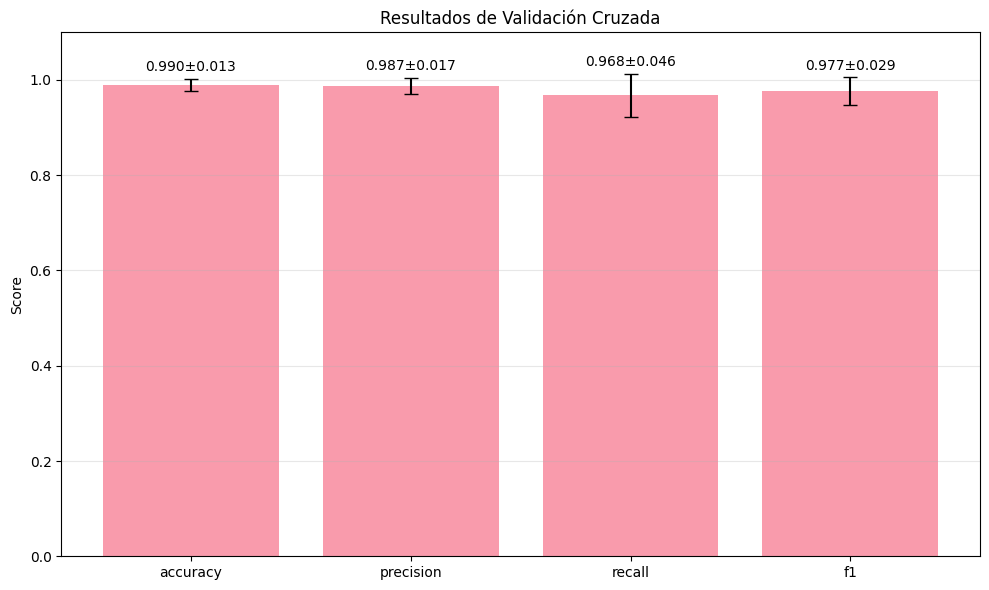

In [ ]:
plot_cv_results(cv_results)

### 3. Curvas de aprendizaje para diferentes métricas

8 min para cada una aproximadamente


Generando curva de aprendizaje para accuracy...


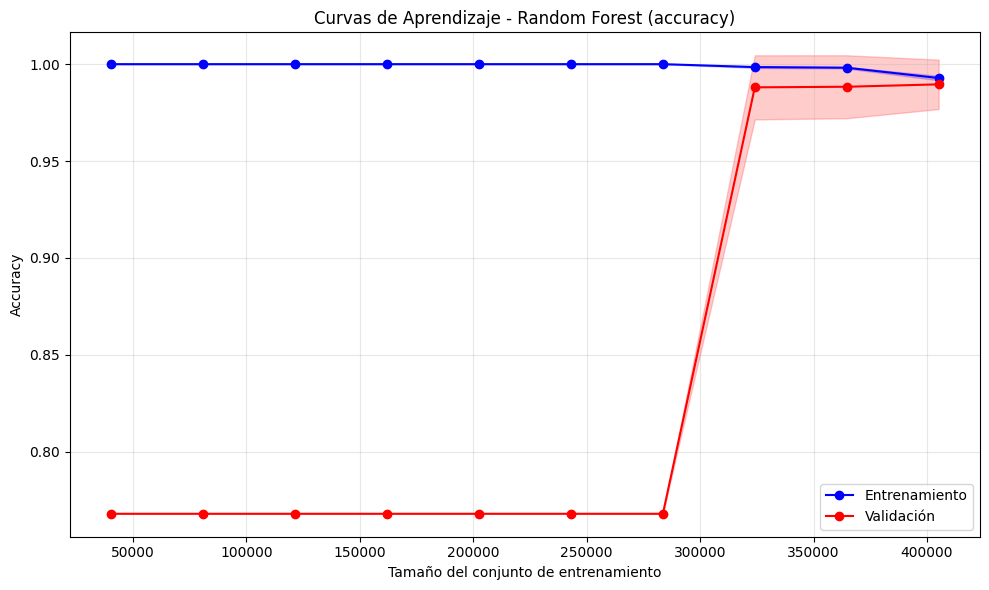


Generando curva de aprendizaje para recall...


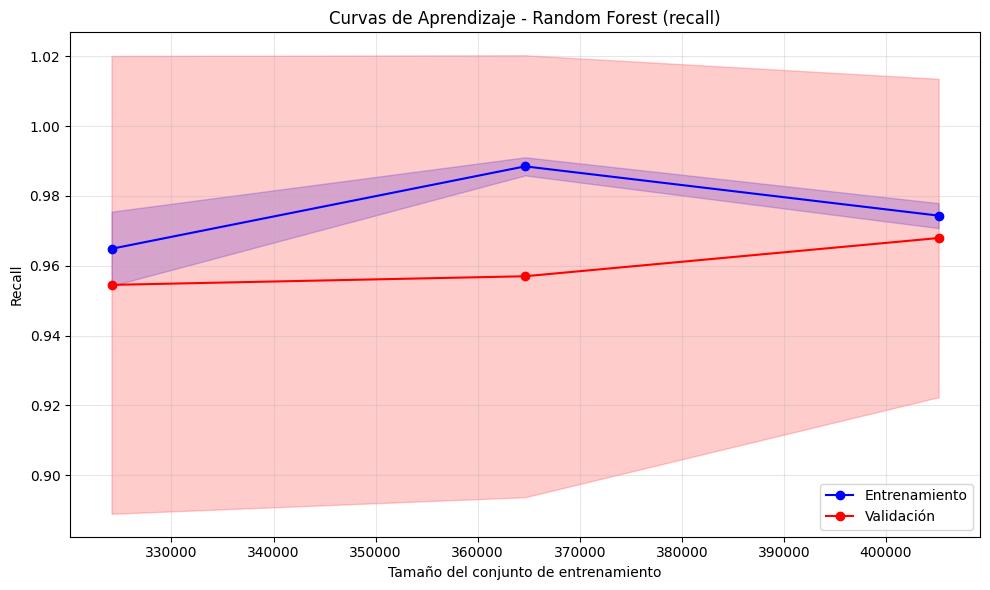


Generando curva de aprendizaje para precision...


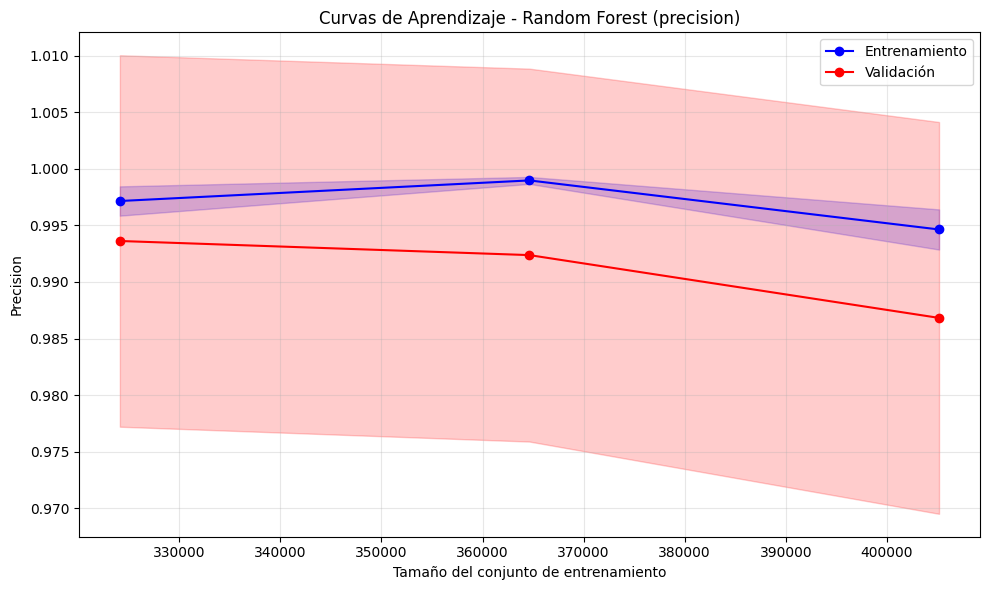

In [ ]:
metrics_to_plot = ['accuracy', 'recall', 'precision']

for metric in metrics_to_plot:
    print(f"\nGenerando curva de aprendizaje para {metric}...")
    plot_learning_curves(model, X, y, cv=10, scoring=metric)

## Paso 9: Búsqueda de Hiperparametros (Fine-tuning)

Este es otro punto importante. Qué nos dice, que nuestro modelo que entrenamos y creamos hace unas celdas, es el mejor para ese conjunto de datos? Para ello podemos buscar los hiperparametros con el objetivo de optimizar nuestro resultado.

**(no ejecutar en la práctica)**

### 1. Curvas de validación para hiperparámetros importantes

#### Para n_estimators

de 10 a 20 min en ejecutar


Generando curvas de validación para hiperparámetros...


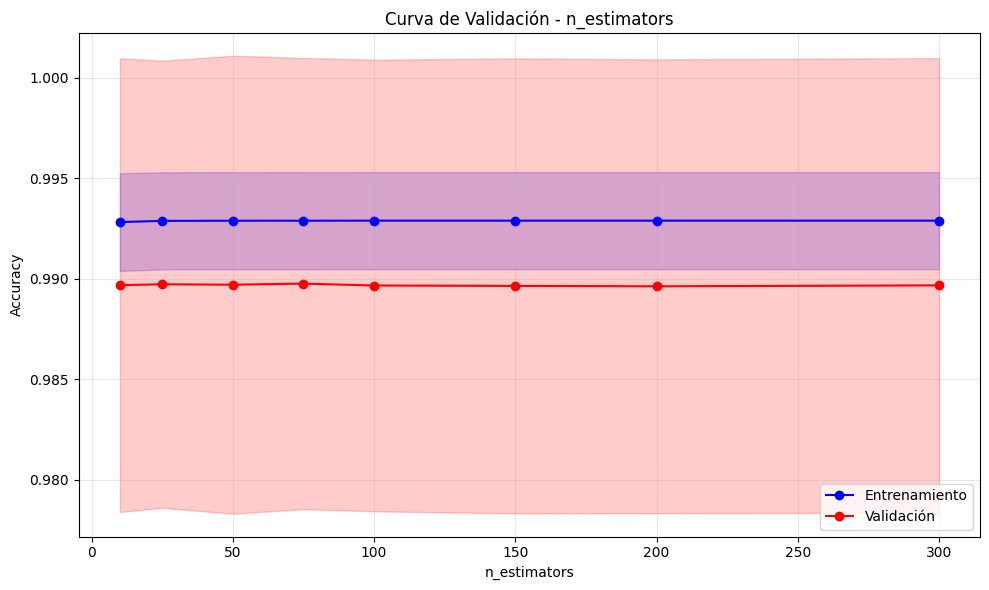

In [ ]:
print("\nGenerando curvas de validación para hiperparámetros...")
n_estimators_range = [10, 25, 50, 75, 100, 150, 200, 300]
plot_validation_curve_param(model, X, y, 'n_estimators', n_estimators_range)

#### Para max_depth

10 min en ejecutar

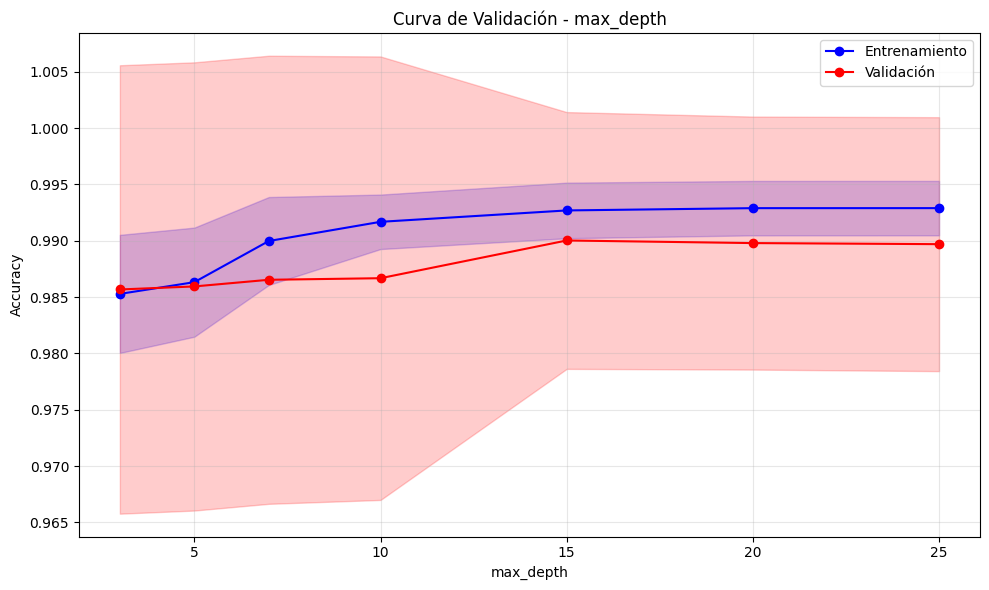

In [ ]:
max_depth_range = [3, 5, 7, 10, 15, 20, 25, None]
plot_validation_curve_param(model, X, y, 'max_depth', max_depth_range)

#### Para min_samples_split

9 min en ejecutar

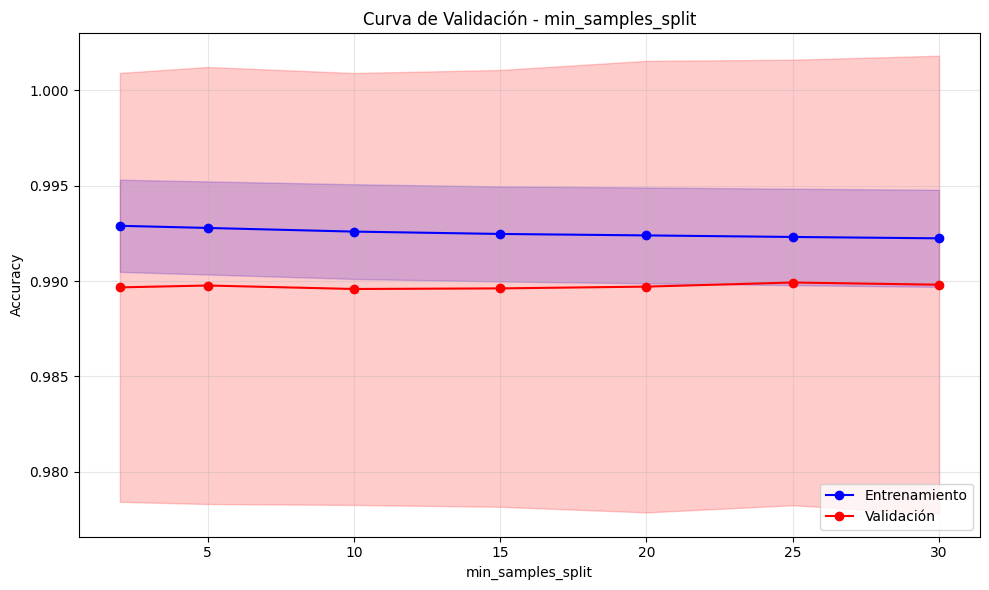

In [ ]:
min_samples_split_range = [2, 5, 10, 15, 20, 25, 30]
plot_validation_curve_param(model, X, y, 'min_samples_split', min_samples_split_range)

## Paso 10: Definir la cuadrícula de hiperparámetros

### Subtask:
Especificar los rangos o valores específicos de los hiperparámetros que se desean probar para el modelo Random Forest (por ejemplo, `n_estimators`, `max_depth`, `min_samples_split`, etc.).


In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
print("Defined parameter grid for hyperparameter search:")
print(param_grid)

Defined parameter grid for hyperparameter search:
{'n_estimators': [50, 100, 150], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}


### Configurar la búsqueda de hiperparámetros

#### Subtask:
Elegir una estrategia de búsqueda como `GridSearchCV` o `RandomizedSearchCV` y configurarla con el modelo, la cuadrícula de parámetros y la métrica de evaluación a optimizar.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Reinicializar el modelo elegido
model = RandomForestClassifier(random_state=42)

# Inicializar una instancia de GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

print("GridSearchCV is configured with the RandomForestClassifier model and the defined parameter grid.")

GridSearchCV is configured with the RandomForestClassifier model and the defined parameter grid.


### Realizar la búsqueda

#### Subtask:
Ejecutar el proceso de búsqueda de hiperparámetros utilizando los datos de entrenamiento. Esto entrenará y evaluará el modelo múltiples veces con diferentes combinaciones de parámetros.


35 min en ejecutar **NO EJECUTAR**

In [ ]:
print("Starting hyperparameter search...")
grid_search.fit(X_train, y_train)
print("Hyperparameter search completed.")

Starting hyperparameter search...
Hyperparameter search completed.


In [ ]:
features = ['url_length', 'has_at', 'dot_count', 'has_https', 'has_ip', 'subdomain_count']
X = df[features]
y = df['type'].apply(lambda x: 0 if x == 'legitimate' else 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print("Starting hyperparameter search...")
grid_search.fit(X_train, y_train)
print("Hyperparameter search completed.")

Data split into training and testing sets.
Starting hyperparameter search...
Hyperparameter search completed.


### Obtener el mejor modelo

#### Subtask:
Una vez completada la búsqueda, extraer el modelo que obtuvo el mejor rendimiento en los datos de validación (interna a la búsqueda).


In [ ]:
best_model = grid_search.best_estimator_
print("Best model found by GridSearchCV:")
print(best_model)
best_params = grid_search.best_params_
print("\nBest hyperparameters found by GridSearchCV:")
print(best_params)

Best model found by GridSearchCV:
RandomForestClassifier(min_samples_split=10, n_estimators=50, random_state=42)

Best hyperparameters found by GridSearchCV:
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 50}


### Evaluar el mejor modelo en el conjunto de prueba

#### Subtask:
Utilizar el mejor modelo encontrado para hacer predicciones sobre el conjunto de prueba (`X_test`, `y_test`) y calcular las métricas de evaluación finales (exactitud, precisión, recall, F1-score, matriz de confusión).


In [ ]:
y_pred_best = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Final Accuracy (Exactitud) with Best Model: {accuracy_best:.4f}")
precision_best = precision_score(y_test, y_pred_best)
print(f"Final Precision (Precisión) with Best Model: {precision_best:.4f}")
recall_best = recall_score(y_test, y_pred_best)
print(f"Final Recall (Exhaustividad/Sensibilidad) with Best Model: {recall_best:.4f}")
f1_best = f1_score(y_test, y_pred_best)
print(f"Final F1-Score with Best Model: {f1_best:.4f}")
cm_best = confusion_matrix(y_test, y_pred_best)
print("\nFinal Confusion Matrix with Best Model:")
print(cm_best)

Final Accuracy (Exactitud) with Best Model: 0.9919
Final Precision (Precisión) with Best Model: 0.9934
Final Recall (Exhaustividad/Sensibilidad) with Best Model: 0.9720
Final F1-Score with Best Model: 0.9825

Final Confusion Matrix with Best Model:
[[68784   137]
 [  592 20523]]


### Comparar métricas

#### Subtask:
Compare the metrics obtained with the optimized model against the metrics of the initial Random Forest model to see if the hyperparameter search improved the performance.


In [ ]:
print("--- Comparison of Model Metrics ---")
print("\nInitial Random Forest Model Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: 0.9821")
# Print Optimized Model Metrics
print("\nOptimized Random Forest Model Metrics:")
print(f"Accuracy: {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall: {recall_best:.4f}")
print(f"F1-Score: {f1_best:.4f}")
# Summary of Comparison
print("\n--- Summary of Improvement ---")
print(f"Accuracy Improvement: {accuracy_best - accuracy:.4f}")
print(f"Precision Improvement: {precision_best - precision:.4f}")
print(f"Recall Improvement: {recall_best - recall:.4f}")
print(f"F1-Score Improvement: {f1_best - 0.9821:.4f}")

print("\nInterpretation:")
if accuracy_best > accuracy:
    print("- Accuracy slightly improved.")
elif accuracy_best < accuracy:
    print("- Accuracy slightly decreased.")
else:
    print("- Accuracy remained the same.")

if precision_best > precision:
    print("- Precision slightly improved.")
elif precision_best < precision:
    print("- Precision slightly decreased.")
else:
    print("- Precision remained the same.")

if recall_best > recall:
    print("- Recall remained the same.")
elif recall_best < recall:
    print("- Recall slightly decreased.")
else:
    print("- Recall remained the same.")

if f1_best > 0.9821:
    print("- F1-Score slightly improved.")
elif f1_best < 0.9821:
     print("- F1-Score slightly decreased.")
else:
     print("- F1-Score remained the same.")

--- Comparison of Model Metrics ---

Initial Random Forest Model Metrics:
Accuracy: 0.9917
Precision: 0.9924
Recall: 0.9720
F1-Score: 0.9821

Optimized Random Forest Model Metrics:
Accuracy: 0.9919
Precision: 0.9934
Recall: 0.9720
F1-Score: 0.9825

--- Summary of Improvement ---
Accuracy Improvement: 0.0002
Precision Improvement: 0.0010
Recall Improvement: 0.0000
F1-Score Improvement: 0.0004

Interpretation:
- Accuracy slightly improved.
- Precision slightly improved.
- Recall remained the same.
- F1-Score slightly improved.


### Guardar el mejor modelo (opcional)

#### Subtask:
If the optimized model shows a significant improvement, save it for future use.


In [ ]:
import joblib
joblib.dump(best_model, 'best_random_forest_model.pkl')
print("Optimized Random Forest model saved as 'best_random_forest_model.pkl'")

Optimized Random Forest model saved as 'best_random_forest_model.pkl'


## Paso 11: Guardar y descargar el modelo

In [ ]:
import joblib
joblib.dump(model, 'modelo_taller_foro.pkl') # Guardar el modelo

['modelo_taller_foro.pkl']

ya lo guardamos, ahora debemos descargarlo a nuestro PC

In [ ]:
from google.colab import files
files.download('modelo_taller_foro.pkl') # Descargar el modelo en la PC local

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Paso 12: Cargar el modelo

In [ ]:
from google.colab import files
import joblib
uploaded = files.upload() # Cargar el modelo a la PC de google colab
modelo_entrenado = joblib.load('modelo_taller_foro.pkl') # pasarlo a una variable para hacer inferencias

Saving modelo_taller_foro.pkl to modelo_taller_foro (1).pkl


## Paso 13: Inferencias

Las inferencias son las predicciones que hace un modelo de ML/DL a los datos de entrada. OJO: estos datos son nuevos, es decir, el modelo no los ha visto.

In [ ]:
# Ejemplo 1: URL legítima típica
nueva_muestra_1 = {
    'url_length': [25],
    'has_at': [0],
    'dot_count': [2],
    'has_https': [1],
    'has_ip': [0],
    'subdomain_count': [1]
}

# Ejemplo 2: URL sospechosa
nueva_muestra_2 = {
    'url_length': [65],
    'has_at': [1],
    'dot_count': [5],
    'has_https': [0],
    'has_ip': [1],
    'subdomain_count': [4]
}

# Convertir a DataFrames
df_muestra_1 = pd.DataFrame(nueva_muestra_1)
df_muestra_2 = pd.DataFrame(nueva_muestra_2)

In [ ]:
pred_1 = modelo_entrenado.predict(df_muestra_1)
pred_2 = modelo_entrenado.predict(df_muestra_2)

print("Predicción muestra 1:", pred_1[0])
print("Predicción muestra 2:", pred_2[0])

Predicción muestra 1: 0
Predicción muestra 2: 1


Recordar que y = df['type'].apply(lambda x: 0 if x == 'legitimate' else 1)

# Ejercicio 2: Aprendizaje supervisado para clasificación de SPAM (versión 1)

Ahora veremos rápidamente un ejemplo similar, solo que en este caso, vamos a cargar el dataset desde una url de forma directa, así como haremos una clasificación de SPAM o no SPAM

## Paso 1: Cargar los datos

In [ ]:
url_spambase = 'https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data'

In [ ]:
# Nombres de características del dataset Spambase

#feature_names = df.columns.tolist() # extraer los nombre de todas las columnas
#feature_names = df.columns[:-1].tolist() # todas excepto la última
#feature_names = [col for col in df.columns if col != 'is_spam'] # todas excepto una específica
feature_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our',
    'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail',
    'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses',
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp',
    'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs',
    'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
    'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re',
    'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_semicolon', 'char_freq_parenthesis',
    'char_freq_bracket', 'char_freq_exclamation', 'char_freq_dollar', 'char_freq_hash',
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total', 'is_spam'
]

# Cargar los datos
df_emails = pd.read_csv(url_spambase, header=None, names=feature_names, sep=',')
print("✅ Dataset Spambase cargado correctamente.")
print("📧 Dataset de Emails Real (Spambase):")
print(df_emails.head())
print(f"\nForma del dataset: {df_emails.shape}")
print(f"\nDistribución: {df_emails['is_spam'].value_counts()[1]} spam, {df_emails['is_spam'].value_counts()[0]} legítimos")

✅ Dataset Spambase cargado correctamente.
📧 Dataset de Emails Real (Spambase):
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_semicolon 

## Paso 2: Preparación y división de los datos

In [ ]:
# Preparar datos para el modelo
X_2 = df_emails.drop('is_spam', axis=1)
y_2 = df_emails['is_spam']

In [ ]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.3, random_state=42, stratify=y_2)

"Al dividir los datos, asegúrate de que la distribución de clases en y_train_2 y y_test_2 sea idéntica a la distribución original en y_2."

In [ ]:
# Escalar características (importante para algunos algoritmos)
scaler_2 = StandardScaler()
X_train_scaled = scaler_2.fit_transform(X_train_2) # Escala y entrena
X_test_scaled = scaler_2.transform(X_test_2) # solo escala

z=(x−μ)/ σ



## Paso 3: Modelos de ML

In [ ]:
# Modelo 1: Regresión Logística
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_2)
lr_pred = lr_model.predict(X_test_scaled)
lr_score = lr_model.score(X_test_scaled, y_test_2)

In [ ]:
# Modelo 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_2, y_train_2) # no es necesario escalar los datos
rf_pred = rf_model.predict(X_test_2)
rf_score = rf_model.score(X_test_2, y_test_2)

In [ ]:
print(f"📊 RESULTADOS DE CLASIFICACIÓN:")
print(f"• Regresión Logística: {lr_score:.3f} precisión")
print(f"• Random Forest: {rf_score:.3f} precisión")

📊 RESULTADOS DE CLASIFICACIÓN:
• Regresión Logística: 0.928 precisión
• Random Forest: 0.956 precisión


### Visualización

/tmp/ipython-input-1367517093.py:32: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1367517093.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


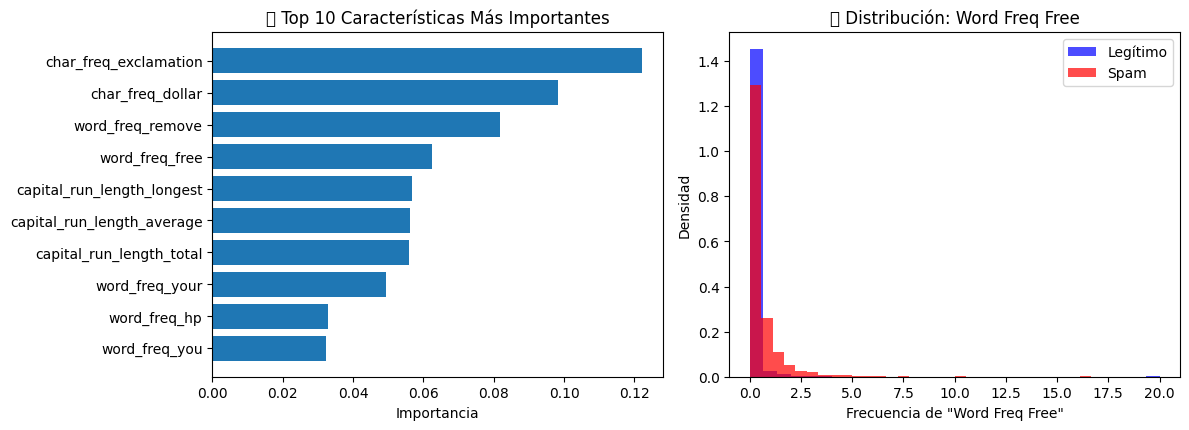

In [ ]:
# Visualización de características más importantes (Random Forest)
feature_importance = rf_model.feature_importances_
top_features_idx = np.argsort(feature_importance)[-10:]  # Top 10 características

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.barh(range(len(top_features_idx)), feature_importance[top_features_idx])
plt.yticks(range(len(top_features_idx)), [X_2.columns[i] for i in top_features_idx])
plt.xlabel('Importancia')
plt.title('🔍 Top 10 Características Más Importantes')

# Distribución de una característica clave por clase
if 'word_freq_free' in X_2.columns:
    key_feature = 'word_freq_free'
elif len(X_2.columns) > 0:
    key_feature = X_2.columns[0]
else:
    key_feature = 'feature_0'

plt.subplot(2, 2, 2)
spam_data = df_emails[df_emails['is_spam'] == 1][key_feature]
ham_data = df_emails[df_emails['is_spam'] == 0][key_feature]

plt.hist(ham_data, bins=30, alpha=0.7, label='Legítimo', color='blue', density=True)
plt.hist(spam_data, bins=30, alpha=0.7, label='Spam', color='red', density=True)
plt.xlabel(f'Frecuencia de "{key_feature.replace("_", " ").title()}"')
plt.ylabel('Densidad')
plt.title(f'📊 Distribución: {key_feature.replace("_", " ").title()}')
plt.legend()

plt.tight_layout()
plt.show()

### Matriz de confusión

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test_2, rf_pred)
print(f"\n📊 MATRIZ DE CONFUSIÓN:")
print("                 Predicción")
print("                Legítimo  Spam")
print(f"Real Legítimo     {cm[0,0]:4d}     {cm[0,1]:4d}")
print(f"Real Spam         {cm[1,0]:4d}     {cm[1,1]:4d}")


📊 MATRIZ DE CONFUSIÓN:
                 Predicción
                Legítimo  Spam
Real Legítimo      815       22
Real Spam           39      505


In [ ]:
# Explicación del contexto de seguridad
print(f"\n🔍 INTERPRETACIÓN EN SEGURIDAD:")
print(f"• Verdaderos Positivos (TP): {cm[1,1]} spam detectado correctamente")
print(f"• Falsos Positivos (FP): {cm[0,1]} emails legítimos marcados como spam")
print(f"• Falsos Negativos (FN): {cm[1,0]} spam NO detectado (¡CRÍTICO!)")
print(f"• Verdaderos Negativos (TN): {cm[0,0]} emails legítimos clasificados correctamente")

print(f"\n⚠️  COSTO DE ERRORES:")
print(f"• Falso Positivo: Email importante en carpeta spam")
print(f"• Falso Negativo: Spam llega a la bandeja de entrada")


🔍 INTERPRETACIÓN EN SEGURIDAD:
• Verdaderos Positivos (TP): 505 spam detectado correctamente
• Falsos Positivos (FP): 22 emails legítimos marcados como spam
• Falsos Negativos (FN): 39 spam NO detectado (¡CRÍTICO!)
• Verdaderos Negativos (TN): 815 emails legítimos clasificados correctamente

⚠️  COSTO DE ERRORES:
• Falso Positivo: Email importante en carpeta spam
• Falso Negativo: Spam llega a la bandeja de entrada


## Paso 4: Métricas de evaluación

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipython-input-2929648266.py:39: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


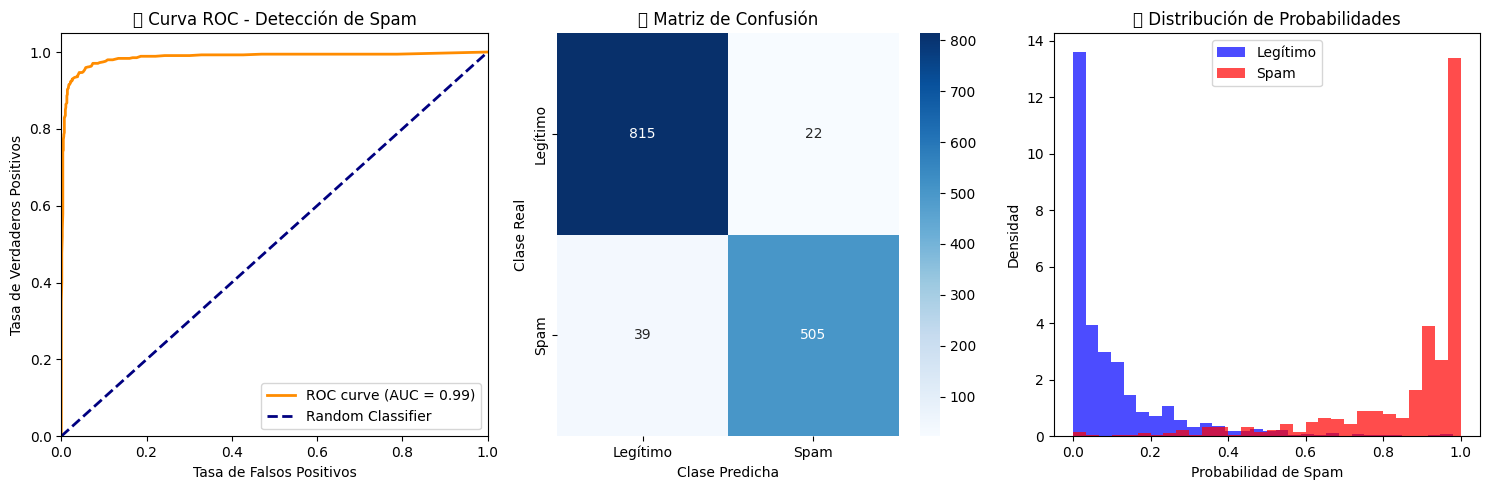

🎯 AUC-ROC: 0.986 (0.5=random, 1.0=perfecto)


In [ ]:
# Visualización de métricas
plt.figure(figsize=(15, 5))

# ROC Curve
plt.subplot(1, 3, 1)
rf_proba = rf_model.predict_proba(X_test_2)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_2, rf_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('📈 Curva ROC - Detección de Spam')
plt.legend(loc="lower right")

# Matriz de confusión visualizada
plt.subplot(1, 3, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítimo', 'Spam'],
            yticklabels=['Legítimo', 'Spam'])
plt.title('📊 Matriz de Confusión')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')

# Distribución de probabilidades
plt.subplot(1, 3, 3)
spam_probs = rf_proba[y_test_2 == 1]
ham_probs = rf_proba[y_test_2 == 0]

plt.hist(ham_probs, bins=30, alpha=0.7, label='Legítimo', color='blue', density=True)
plt.hist(spam_probs, bins=30, alpha=0.7, label='Spam', color='red', density=True)
plt.xlabel('Probabilidad de Spam')
plt.ylabel('Densidad')
plt.title('📊 Distribución de Probabilidades')
plt.legend()
plt.tight_layout()
plt.show()
print(f"🎯 AUC-ROC: {roc_auc:.3f} (0.5=random, 1.0=perfecto)")

# Ejercicio 3: Aprendizaje supervisado para clasificación de SPAM (versión 2)

Ahora en este ejercicio usaremos otro dataset y convertiremos las letras en algo que nuestro modelo pueda entender.

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
url_emails = "https://raw.githubusercontent.com/platzi/curso_fundamentos_ia_y-machine_learning/main/Emails_Simulados.csv"
df = pd.read_csv(url_emails)

In [ ]:
df.head()

,email,clase
0,¿Podemos reagendar la cita para el viernes?,normal
1,¿Podemos reagendar la cita para el viernes?,normal
2,El reporte está listo para revisión,normal
3,"Feliz cumpleaños, espero que tengas un día mar...",normal
4,¿Podemos reagendar la cita para el viernes?,normal


In [ ]:
# Convertir texto a vectores numéricos
vectorizador = TfidfVectorizer(stop_words='spanish')
vectorizador = TfidfVectorizer()
X_3 = vectorizador.fit_transform(df['email'])
y_3 = df['clase']

stop_words='spanish': Esta línea crea una instancia del transformador TfidfVectorizer de la librería scikit-learn.
TfidfVectorizer se utiliza para convertir una colección de documentos de texto en una matriz de características TF-IDF (Term Frequency-Inverse Document Frequency).

TF-IDF es una técnica que asigna pesos a las palabras basándose en qué tan frecuente son en un documento (TF) y qué tan raras son en todo el conjunto de documentos (IDF). Las palabras que aparecen con frecuencia en un documento pero son raras en otros documentos suelen tener un TF-IDF alto.

stop_words='spanish': Este parámetro indica al vectorizador que ignore las "stop words" del español. Las "stop words" son palabras comunes (como "el", "la", "y", "es", etc.) que generalmente no aportan mucho significado para la clasificación y pueden ser eliminadas para reducir el ruido.

vectorizador = TfidfVectorizer(): Esta línea reasigna la variable vectorizador, creando una nueva instancia de TfidfVectorizer sin especificar stop_words. Esto significa que en la ejecución actual, no se eliminarán las "stop words".

fit_transform() hace dos cosas:
1. fit(): Aprende el vocabulario (todas las palabras únicas) del texto en la columna 'email' y calcula los valores IDF para cada palabra.
2. transform(): Convierte cada correo electrónico en una fila de una matriz numérica. Cada columna de esta matriz corresponde a una palabra del vocabulario aprendido, y el valor en cada celda es el puntaje TF-IDF de esa palabra en ese correo electrónico.

El resultado, que es una matriz dispersa (sparse matrix) ya que la mayoría de los valores serán cero, se almacena en la variable X_3.
- X_3 representa las características numéricas de los correos electrónicos.

En resumen, esta celda toma el texto de los correos electrónicos y lo transforma en un formato numérico (una matriz TF-IDF) y separa las etiquetas para preparar los datos para el entrenamiento de un modelo de machine learning.

In [ ]:
print(X_3.shape)
print(y_3.shape)

(200, 59)
(200,)


utilizamos 59 características (palabras)

In [ ]:
print(X_3)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1369 stored elements and shape (200, 59)>
  Coords	Values
  (0, 40)	0.40694963793983835
  (0, 46)	0.40694963793983835
  (0, 29)	0.40694963793983835
  (0, 5)	0.40694963793983835
  (0, 37)	0.29972721936613045
  (0, 16)	0.28657207622903536
  (0, 57)	0.40694963793983835
  (1, 40)	0.40694963793983835
  (1, 46)	0.40694963793983835
  (1, 29)	0.40694963793983835
  (1, 5)	0.40694963793983835
  (1, 37)	0.29972721936613045
  (1, 16)	0.28657207622903536
  (1, 57)	0.40694963793983835
  (2, 37)	0.2818239183920664
  (2, 16)	0.26945455803251944
  (2, 47)	0.460426302511499
  (2, 21)	0.460426302511499
  (2, 31)	0.460426302511499
  (2, 49)	0.460426302511499
  (3, 22)	0.3605647972090049
  (3, 10)	0.3605647972090049
  (3, 20)	0.3605647972090049
  (3, 45)	0.3605647972090049
  (3, 53)	0.3605647972090049
  :	:
  (196, 34)	0.42796761217686297
  (196, 38)	0.42796761217686297
  (196, 39)	0.42796761217686297
  (196, 50)	0.42796761217686297
  (197, 37)	

solo se almacenan los 1369 valores TF-IDF que no son cero, lo cual es mucho menor que el total de elementos posibles (200 * 59 = 11800).

In [ ]:
# Dividir en entrenamiento y prueba
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

In [ ]:
modelo3 = MultinomialNB()
modelo3.fit(X_train3, y_train3)
y_pred3 = modelo3.predict(X_test3)

In [ ]:
print("Reporte de clasificación:")
print(classification_report(y_test3, y_pred3))
print(f"Precisión: {accuracy_score(y_test3, y_pred3):.2%}")

Reporte de clasificación:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        21
        spam       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Precisión: 100.00%
